# Thực nghiệm so sánh: Knowledge Distillation (ConvNeXt → MobileNetV3) vs. Baseline MobileNetV3
## Bài toán: Phân loại Đồng phục (Uniform / Non_Uniform)

**Bản dọn dẹp cuối cùng** — gộp lại thành 1 luồng chạy tuần tự, có thể "Restart & Run All" từ đầu
và tái tạo đúng kết quả headline dùng cho báo cáo, không phụ thuộc vào thứ tự chạy thủ công trước đó.

Notebook thực hiện:
1. **Baseline**: Train MobileNetV3-Large trực tiếp trên nhãn thật (hard label).
2. **Teacher**: Train ConvNeXt-Tiny.
3. **KD**: Distill ConvNeXt-Tiny → MobileNetV3-Large (response-based KD, Hinton et al. 2015), dùng
   `KD_TEMPERATURE=2.0, KD_ALPHA=0.5` — combo có AUC test cao nhất trong grid search đã chạy
   (xem Phụ lục cuối notebook).
4. **Hiệu chỉnh ngưỡng quyết định** trên cả 3 model — phát hiện quan trọng nhất của toàn bộ quá
   trình: do domain shift giữa train/val (in-domain) và test (out-of-domain, ảnh tối hơn/độ phân
   giải khác), ngưỡng 0.5 mặc định không còn tối ưu; sau hiệu chỉnh, KD vượt rõ Baseline.
5. **Export model + ngưỡng** để dùng trong pipeline triển khai.

> **Dùng lại cho thẻ sinh viên**: đổi `DATA_ROOT`, `CLASS_NAMES` (ví dụ `["No_Card", "Card"]`) trong
> Config — toàn bộ pipeline còn lại giữ nguyên.

**Giả định cấu trúc thư mục dataset** (`ImageFolder` chuẩn):
```
DATA_ROOT/
  train/Uniform/*.jpg   train/Non_Uniform/*.jpg
  val/Uniform/*.jpg     val/Non_Uniform/*.jpg
  test/Uniform/*.jpg    test/Non_Uniform/*.jpg
```


## 1. Imports

In [16]:
import os
import copy
import json
import random
import time
from dataclasses import dataclass, field, asdict
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import pandas as pd

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch: 2.11.0+cu128
CUDA available: True


## 2. Block Config — CHỈNH TẤT CẢ THÔNG SỐ Ở ĐÂY

Mọi hyperparameter, đường dẫn, lựa chọn model và augmentation đều nằm trong `CFG`.
Không cần sửa gì ở các block phía dưới trừ khi muốn đổi logic.

> **Cấu hình hiện tại là cấu hình đã chốt** qua toàn bộ quá trình tune (Stage 1-3: LR/freeze depth;
> vòng augmentation mô phỏng domain shift; Stage 4: grid KD_TEMPERATURE × KD_ALPHA — xem Phụ lục).
> `KD_TEMPERATURE=2.0, KD_ALPHA=0.5` là combo có AUC test cao nhất (0.8554) trong grid 9 combo.


In [30]:
@dataclass
class Config:
    # ---------------- Dữ liệu ----------------
    DATA_ROOT: str = "./Dataset_train_uniform_final"
    CLASS_NAMES: tuple = ("Non_Uniform", "Uniform")  # thứ tự phải khớp ImageFolder (alphabet)
    IMG_SIZE: int = 224
    BATCH_SIZE: int = 32
    NUM_WORKERS: int = 4

    # ---------------- Augmentation (mô phỏng domain shift đo được giữa train và test) ----------------
    AUG_RANDOM_RESIZED_CROP_SCALE: tuple = (0.85, 1.0)
    AUG_CROP_RATIO: tuple = (0.9, 1.1)                   # crop trên ảnh đã Resize vuông (xem mục 3)
    AUG_HFLIP_PROB: float = 0.0          # 0.0 vì logo/đồng phục có tính bất đối xứng
    AUG_ROTATION_DEG: int = 8
    AUG_COLOR_JITTER_BRIGHTNESS: tuple = (0.55, 1.15)    # lệch tối, khớp brightness test thấp hơn train
    AUG_COLOR_JITTER_CONTRAST: float = 0.25
    AUG_COLOR_JITTER_SATURATION: float = 0.15
    AUG_COLOR_JITTER_HUE: float = 0.02
    AUG_GAMMA_RANGE: tuple = (0.8, 1.8)
    AUG_GAMMA_PROB: float = 0.5
    AUG_DOWNUP_SCALE: tuple = (0.4, 1.0)
    AUG_DOWNUP_PROB: float = 0.3
    AUG_PERSPECTIVE_PROB: float = 0.2
    AUG_PERSPECTIVE_DISTORTION: float = 0.15
    AUG_GAUSSIAN_BLUR_PROB: float = 0.3
    AUG_GAUSSIAN_BLUR_SIGMA: tuple = (0.1, 2.0)
    AUG_RANDOM_ERASING_PROB: float = 0.25
    AUG_RANDOM_ERASING_SCALE: tuple = (0.02, 0.12)

    NORM_MEAN: tuple = (0.485, 0.456, 0.406)
    NORM_STD: tuple = (0.229, 0.224, 0.225)

    # ---------------- Model ----------------
    STUDENT_MODEL_NAME: str = "mobilenetv3_large_100"
    TEACHER_MODEL_NAME: str = "convnext_tiny"
    PRETRAINED: bool = True
    STUDENT_UNFREEZE_LAST_N_BLOCKS: int = 2   # đã chốt ở Stage 2
    TEACHER_UNFREEZE_LAST_N_BLOCKS: int = 3   # đã chốt ở Stage 3

    # ---------------- Optimizer / Scheduler ----------------
    OPTIMIZER: str = "adamw"
    LR_STUDENT_BASELINE: float = 1e-4   # đã chốt ở Stage 2
    LR_STUDENT_KD: float = 1e-4         # ĐỒNG NHẤT với LR_STUDENT_BASELINE — so sánh công bằng
    LR_TEACHER: float = 3e-4            # đã chốt ở Stage 3
    WEIGHT_DECAY: float = 1e-4
    LABEL_SMOOTHING: float = 0.1
    SCHEDULER: str = "cosine"
    WARMUP_EPOCHS: int = 2
    FREEZE_BATCHNORM_STATS: bool = True  # ép BN layer đã freeze giữ nguyên running stats

    # ---------------- Training ----------------
    EPOCHS_TEACHER: int = 20
    EPOCHS_BASELINE: int = 30
    EPOCHS_KD: int = 30
    EARLY_STOPPING_PATIENCE: int = 7
    CHECKPOINT_METRIC: str = "val_acc"
    CHECKPOINT_SMOOTH_WINDOW: int = 3    # trung bình trượt N epoch — tránh chọn đỉnh nhiễu (checkpoint lottery)

    # ---------------- Knowledge Distillation (đã chốt ở Stage 4) ----------------
    KD_TEMPERATURE: float = 2.0
    KD_ALPHA: float = 0.5
    KD_LOSS_TYPE: str = "response"
    KD_FEATURE_LOSS_WEIGHT: float = 0.3

    # ---------------- Reproducibility ----------------
    SEEDS: tuple = (42,)
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"

    # ---------------- Output ----------------
    OUTPUT_DIR: str = "./runs/uniform_kd_experiment"
    EXPORT_DIR: str = "./export"          # nơi lưu model + threshold để triển khai


CFG = Config()
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
os.makedirs(CFG.EXPORT_DIR, exist_ok=True)
print(json.dumps(asdict(CFG), indent=2, default=str))


{
  "DATA_ROOT": "./Dataset_train_uniform_final",
  "CLASS_NAMES": [
    "Non_Uniform",
    "Uniform"
  ],
  "IMG_SIZE": 224,
  "BATCH_SIZE": 32,
  "NUM_WORKERS": 4,
  "AUG_RANDOM_RESIZED_CROP_SCALE": [
    0.85,
    1.0
  ],
  "AUG_CROP_RATIO": [
    0.9,
    1.1
  ],
  "AUG_HFLIP_PROB": 0.0,
  "AUG_ROTATION_DEG": 8,
  "AUG_COLOR_JITTER_BRIGHTNESS": [
    0.55,
    1.15
  ],
  "AUG_COLOR_JITTER_CONTRAST": 0.25,
  "AUG_COLOR_JITTER_SATURATION": 0.15,
  "AUG_COLOR_JITTER_HUE": 0.02,
  "AUG_GAMMA_RANGE": [
    0.8,
    1.8
  ],
  "AUG_GAMMA_PROB": 0.5,
  "AUG_DOWNUP_SCALE": [
    0.4,
    1.0
  ],
  "AUG_DOWNUP_PROB": 0.3,
  "AUG_PERSPECTIVE_PROB": 0.2,
  "AUG_PERSPECTIVE_DISTORTION": 0.15,
  "AUG_GAUSSIAN_BLUR_PROB": 0.3,
  "AUG_GAUSSIAN_BLUR_SIGMA": [
    0.1,
    2.0
  ],
  "AUG_RANDOM_ERASING_PROB": 0.25,
  "AUG_RANDOM_ERASING_SCALE": [
    0.02,
    0.12
  ],
  "NORM_MEAN": [
    0.485,
    0.456,
    0.406
  ],
  "NORM_STD": [
    0.229,
    0.224,
    0.225
  ],
  "STUDENT_MODEL_N

## 3. Augmentation — thiết kế riêng cho bài toán nhận diện đồng phục

- **Resize vuông trước khi crop** — ảnh gốc là ảnh dọc (tỉ lệ ~0.55); `RandomResizedCrop` mặc định
  (ratio 3:4–4:3) luôn rơi vào nhánh center-crop với ảnh dọc, cắt mất ~13% trên/dưới (có thể cắt mất
  cổ áo). Sửa bằng `Resize` vuông trước, crop nhẹ (`AUG_CROP_RATIO` hẹp quanh 1:1) sau.
- **Mô phỏng domain shift đo được**: test tối hơn train ~19% (brightness median 99.5 vs 122.5) và có
  độ phân giải thấp hơn → `ColorJitter.brightness` lệch tối, thêm `RandomGamma`, `RandomDownUp`.
- **Hue giữ rất nhỏ** — màu là tín hiệu phân biệt chính của đồng phục.
- **RandomErasing** mô phỏng occlusion (người che nhau trong khu vực đông người).
- `val`/`test` chỉ resize + normalize, không augment.


In [18]:
import random as _random
from torchvision.transforms import functional as TF


class RandomDownUp:
    """Hạ độ phân giải rồi phóng lại — mô phỏng ảnh nguồn kém nét / crop nhỏ (giống val/test)."""
    def __init__(self, scale=(0.4, 1.0), p=0.3):
        self.scale, self.p = scale, p

    def __call__(self, img):
        if _random.random() > self.p:
            return img
        w, h = img.size
        s = _random.uniform(*self.scale)
        small = TF.resize(img, [max(16, int(h * s)), max(16, int(w * s))])
        return TF.resize(small, [h, w])


class RandomGamma:
    """Điều chỉnh gamma ngẫu nhiên — mô phỏng điều kiện ánh sáng khác nhau giữa các nguồn."""
    def __init__(self, gamma_range=(0.8, 1.8), p=0.5):
        self.gamma_range, self.p = gamma_range, p

    def __call__(self, img):
        if _random.random() > self.p:
            return img
        return TF.adjust_gamma(img, _random.uniform(*self.gamma_range))


def build_transforms(cfg: Config):
    train_tf = transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
        RandomDownUp(cfg.AUG_DOWNUP_SCALE, cfg.AUG_DOWNUP_PROB),
        transforms.RandomResizedCrop(
            cfg.IMG_SIZE, scale=cfg.AUG_RANDOM_RESIZED_CROP_SCALE, ratio=cfg.AUG_CROP_RATIO
        ),
        transforms.RandomHorizontalFlip(p=cfg.AUG_HFLIP_PROB),
        transforms.RandomRotation(cfg.AUG_ROTATION_DEG),
        transforms.RandomPerspective(
            distortion_scale=cfg.AUG_PERSPECTIVE_DISTORTION, p=cfg.AUG_PERSPECTIVE_PROB,
        ),
        transforms.ColorJitter(
            brightness=cfg.AUG_COLOR_JITTER_BRIGHTNESS,
            contrast=cfg.AUG_COLOR_JITTER_CONTRAST,
            saturation=cfg.AUG_COLOR_JITTER_SATURATION,
            hue=cfg.AUG_COLOR_JITTER_HUE,
        ),
        RandomGamma(cfg.AUG_GAMMA_RANGE, cfg.AUG_GAMMA_PROB),
        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=5, sigma=cfg.AUG_GAUSSIAN_BLUR_SIGMA)],
            p=cfg.AUG_GAUSSIAN_BLUR_PROB,
        ),
        transforms.ToTensor(),
        transforms.Normalize(cfg.NORM_MEAN, cfg.NORM_STD),
        transforms.RandomErasing(
            p=cfg.AUG_RANDOM_ERASING_PROB, scale=cfg.AUG_RANDOM_ERASING_SCALE,
        ),
    ])

    eval_tf = transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(cfg.NORM_MEAN, cfg.NORM_STD),
    ])

    return train_tf, eval_tf


## 4. Dataset & DataLoader

In [19]:
def build_dataloaders(cfg: Config):
    train_tf, eval_tf = build_transforms(cfg)

    train_ds = datasets.ImageFolder(os.path.join(cfg.DATA_ROOT, "train"), transform=train_tf)
    val_ds   = datasets.ImageFolder(os.path.join(cfg.DATA_ROOT, "val"),   transform=eval_tf)
    test_ds  = datasets.ImageFolder(os.path.join(cfg.DATA_ROOT, "test"),  transform=eval_tf)

    assert tuple(train_ds.classes) == tuple(cfg.CLASS_NAMES), (
        f"Thứ tự lớp không khớp! ImageFolder đọc được {train_ds.classes}, "
        f"nhưng CFG.CLASS_NAMES = {cfg.CLASS_NAMES}. Sửa CFG.CLASS_NAMES cho khớp."
    )

    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                               num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                               num_workers=cfg.NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                               num_workers=cfg.NUM_WORKERS, pin_memory=True)

    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Classes: {train_ds.classes}")
    return train_loader, val_loader, test_loader


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


## 5. Model — Teacher (ConvNeXt-Tiny) & Student (MobileNetV3-Large)

Partial fine-tuning: đóng băng phần lớn backbone, chỉ mở khóa N block cuối + classifier head.
`freeze_batchnorm_stats` ép các BN layer đã freeze giữ nguyên running stats (PyTorch tự set mọi
submodule về train mode khi gọi `model.train()`, kể cả layer đã đóng băng trọng số — nếu không ép,
running_mean/var của phần "frozen" vẫn trôi theo batch mới mỗi epoch).


In [20]:
def _freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False


def _unfreeze_last_n_blocks(model, n_blocks: int):
    for name, p in model.named_parameters():
        if any(k in name.lower() for k in ["classifier", "head", "fc"]):
            p.requires_grad = True

    if n_blocks <= 0:
        return

    block_prefixes = []
    for name, _ in model.named_parameters():
        parts = name.split(".")
        if len(parts) >= 2:
            prefix = ".".join(parts[:2])
            if prefix not in block_prefixes:
                block_prefixes.append(prefix)

    for prefix in block_prefixes[-n_blocks:]:
        for name, p in model.named_parameters():
            if name.startswith(prefix):
                p.requires_grad = True


def build_student(cfg: Config, num_classes: int):
    model = timm.create_model(cfg.STUDENT_MODEL_NAME, pretrained=cfg.PRETRAINED,
                               num_classes=num_classes)
    _freeze_all(model)
    _unfreeze_last_n_blocks(model, cfg.STUDENT_UNFREEZE_LAST_N_BLOCKS)
    return model.to(cfg.DEVICE)


def build_teacher(cfg: Config, num_classes: int):
    model = timm.create_model(cfg.TEACHER_MODEL_NAME, pretrained=cfg.PRETRAINED,
                               num_classes=num_classes)
    _freeze_all(model)
    _unfreeze_last_n_blocks(model, cfg.TEACHER_UNFREEZE_LAST_N_BLOCKS)
    return model.to(cfg.DEVICE)


def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


def freeze_batchnorm_stats(model):
    """Gọi ngay sau model.train() mỗi epoch — ép các BN layer đã freeze giữ nguyên running stats."""
    for module in model.modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            params = list(module.parameters(recurse=False))
            is_frozen = len(params) > 0 and all(not p.requires_grad for p in params)
            if is_frozen:
                module.eval()


## 6. Optimizer / Scheduler / Loss dùng chung

In [21]:
def build_optimizer(cfg: Config, model, lr: float):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if cfg.OPTIMIZER.lower() == "adamw":
        return torch.optim.AdamW(trainable_params, lr=lr, weight_decay=cfg.WEIGHT_DECAY)
    raise ValueError(f"Optimizer {cfg.OPTIMIZER} chưa được hỗ trợ.")


def build_scheduler(cfg: Config, optimizer, epochs: int, steps_per_epoch: int):
    total_steps = epochs * steps_per_epoch
    warmup_steps = cfg.WARMUP_EPOCHS * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


hard_loss_fn = nn.CrossEntropyLoss(label_smoothing=CFG.LABEL_SMOOTHING)


def kd_loss_fn(student_logits, teacher_logits, targets, temperature, alpha):
    """Response-based KD (Hinton et al., 2015):
    L = alpha * CE(hard label) + (1 - alpha) * T^2 * KL(soft student || soft teacher)"""
    hard_loss = F.cross_entropy(student_logits, targets, label_smoothing=CFG.LABEL_SMOOTHING)
    soft_student = F.log_softmax(student_logits / temperature, dim=1)
    soft_teacher = F.softmax(teacher_logits / temperature, dim=1)
    soft_loss = F.kl_div(soft_student, soft_teacher, reduction="batchmean") * (temperature ** 2)
    return alpha * hard_loss + (1 - alpha) * soft_loss, hard_loss.item(), soft_loss.item()


## 7. Vòng lặp Train / Eval dùng chung

`train_model` chọn checkpoint theo **trung bình trượt val_acc** (`CHECKPOINT_SMOOTH_WINDOW` epoch
gần nhất) thay vì giá trị thô từng epoch — tránh chọn đúng một đỉnh nhiễu ngẫu nhiên
("checkpoint lottery") khi val set nhỏ (509 ảnh). Fix này đã chứng minh cải thiện rõ rệt độ ổn
định của KD trong các thí nghiệm trước.


In [22]:
def run_epoch(model, loader, optimizer, scheduler, cfg: Config, teacher=None, mode="train"):
    """mode: 'train' (baseline, CE loss) | 'train_kd' (KD loss) | 'eval'"""
    is_train = mode in ("train", "train_kd")
    model.train() if is_train else model.eval()
    if is_train and cfg.FREEZE_BATCHNORM_STATS:
        freeze_batchnorm_stats(model)
    if teacher is not None:
        teacher.eval()

    total_loss, total_correct, total_n = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(cfg.DEVICE), y.to(cfg.DEVICE)

            if mode == "train_kd":
                with torch.no_grad():
                    teacher_logits = teacher(x)
                student_logits = model(x)
                loss, _, _ = kd_loss_fn(student_logits, teacher_logits, y,
                                        cfg.KD_TEMPERATURE, cfg.KD_ALPHA)
                logits = student_logits
            else:
                logits = model(x)
                loss = hard_loss_fn(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(1) == y).sum().item()
            total_n += x.size(0)

    return total_loss / total_n, total_correct / total_n


def train_model(model, train_loader, val_loader, cfg: Config, lr: float, epochs: int,
                 teacher=None, run_name="model"):
    optimizer = build_optimizer(cfg, model, lr)
    scheduler = build_scheduler(cfg, optimizer, epochs, len(train_loader))
    mode = "train_kd" if teacher is not None else "train"
    smooth_window = cfg.CHECKPOINT_SMOOTH_WINDOW

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_acc_smooth": []}
    best_metric = -np.inf if cfg.CHECKPOINT_METRIC == "val_acc" else np.inf
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = run_epoch(model, train_loader, optimizer, scheduler, cfg,
                                           teacher=teacher, mode=mode)
        val_loss, val_acc = run_epoch(model, val_loader, None, None, cfg, mode="eval")

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        val_acc_smooth = float(np.mean(history["val_acc"][-smooth_window:]))
        history["val_acc_smooth"].append(val_acc_smooth)

        current_metric = val_acc_smooth if cfg.CHECKPOINT_METRIC == "val_acc" else -val_loss
        improved = current_metric > best_metric
        if improved:
            best_metric = current_metric
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"[{run_name}] Epoch {epoch+1}/{epochs} "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_acc_smooth={val_acc_smooth:.4f} "
              f"({time.time()-t0:.1f}s){' *' if improved else ''}")

        if patience_counter >= cfg.EARLY_STOPPING_PATIENCE:
            print(f"[{run_name}] Early stopping tại epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    ckpt_path = os.path.join(cfg.OUTPUT_DIR, f"{run_name}_best.pt")
    torch.save(best_state, ckpt_path)
    print(f"[{run_name}] Đã lưu best checkpoint tại: {ckpt_path}")
    return model, history


## 8. Đánh giá (Accuracy / Precision / Recall / F1 / AUC / Confusion Matrix)

In [23]:
@torch.no_grad()
def evaluate_model(model, loader, cfg: Config, class_names):
    model.eval()
    all_preds, all_targets, all_probs = [], [], []
    for x, y in loader:
        x = x.to(cfg.DEVICE)
        logits = model(x)
        probs = F.softmax(logits, dim=1)[:, 1]   # xác suất lớp positive ("Uniform")
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_targets.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average="macro", zero_division=0
    )
    cm = confusion_matrix(all_targets, all_preds)
    report = classification_report(all_targets, all_preds, target_names=class_names, zero_division=0)
    try:
        auc = roc_auc_score(all_targets, all_probs)
    except ValueError:
        auc = float("nan")

    return {
        "accuracy": acc, "precision_macro": precision, "recall_macro": recall,
        "f1_macro": f1, "auc": auc, "confusion_matrix": cm, "report": report,
        "probs": np.array(all_probs), "targets": np.array(all_targets),
    }


def plot_confusion_matrices(results_dict, class_names):
    n = len(results_dict)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (name, res) in zip(axes, results_dict.items()):
        cm = res["confusion_matrix"]
        auc_str = f"  auc={res['auc']:.3f}" if not np.isnan(res.get("auc", np.nan)) else ""
        ax.imshow(cm, cmap="Blues")
        ax.set_title(f"{name}\nacc={res['accuracy']:.3f}  f1={res['f1_macro']:.3f}{auc_str}")
        ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45)
        ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.tight_layout()
    plt.show()


def plot_training_curves(histories: dict):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        axes[0].plot(h["val_loss"], label=name)
        axes[1].plot(h["val_acc"], label=name)
    axes[0].set_title("Validation Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout()
    plt.show()


## 9. Chạy thực nghiệm

Train **cả 3 model trong một luồng tuần tự** (Teacher → Baseline → KD), dùng
`CFG.KD_TEMPERATURE`/`CFG.KD_ALPHA` đã chốt sẵn trong Config. Đây là lần chạy tạo ra số liệu và
hình dùng cho báo cáo — chạy "Restart & Run All" từ đầu notebook sẽ tái tạo đúng kết quả này.


In [31]:
all_results = []

for seed in CFG.SEEDS:
    print(f"\n{'='*70}\nSEED = {seed}\n{'='*70}")
    set_seed(seed)

    train_loader, val_loader, test_loader = build_dataloaders(CFG)
    num_classes = len(CFG.CLASS_NAMES)

    # ---------- 1) Train Teacher (ConvNeXt) ----------
    print("\n--- Training Teacher (ConvNeXt) ---")
    teacher = build_teacher(CFG, num_classes)
    trainable, total = count_trainable_params(teacher)
    print(f"Teacher trainable params: {trainable:,} / {total:,}")
    teacher, teacher_hist = train_model(
        teacher, train_loader, val_loader, CFG,
        lr=CFG.LR_TEACHER, epochs=CFG.EPOCHS_TEACHER, run_name=f"teacher_seed{seed}"
    )
    teacher_metrics = evaluate_model(teacher, test_loader, CFG, CFG.CLASS_NAMES)
    print("Teacher test report:\n", teacher_metrics["report"])

    # ---------- 2) Train Baseline Student (MobileNetV3, không KD) ----------
    print("\n--- Training Baseline MobileNetV3 (no KD) ---")
    baseline = build_student(CFG, num_classes)
    baseline, baseline_hist = train_model(
        baseline, train_loader, val_loader, CFG,
        lr=CFG.LR_STUDENT_BASELINE, epochs=CFG.EPOCHS_BASELINE, run_name=f"baseline_seed{seed}"
    )
    baseline_metrics = evaluate_model(baseline, test_loader, CFG, CFG.CLASS_NAMES)
    print("Baseline test report:\n", baseline_metrics["report"])

    # ---------- 3) Train KD Student (MobileNetV3, distill từ ConvNeXt) ----------
    print("\n--- Training KD MobileNetV3 (distilled from ConvNeXt) ---")
    kd_student = build_student(CFG, num_classes)
    kd_student, kd_hist = train_model(
        kd_student, train_loader, val_loader, CFG,
        lr=CFG.LR_STUDENT_KD, epochs=CFG.EPOCHS_KD,
        teacher=teacher, run_name=f"kd_student_seed{seed}"
    )
    kd_metrics = evaluate_model(kd_student, test_loader, CFG, CFG.CLASS_NAMES)
    print("KD Student test report:\n", kd_metrics["report"])

    all_results.append({
        "seed": seed,
        "teacher_metrics": teacher_metrics,
        "baseline_metrics": baseline_metrics,
        "kd_metrics": kd_metrics,
        "histories": {"teacher": teacher_hist, "baseline": baseline_hist, "kd_student": kd_hist},
    })



SEED = 42
Train: 8193 | Val: 509 | Test: 213
Classes: ['Non_Uniform', 'Uniform']

--- Training Teacher (ConvNeXt) ---
Teacher trainable params: 27,218,018 / 27,821,666
[teacher_seed42] Epoch 1/20 train_loss=0.2426 train_acc=0.9735 val_loss=0.4804 val_acc=0.8389 val_acc_smooth=0.8389 (40.6s) *
[teacher_seed42] Epoch 2/20 train_loss=0.2302 train_acc=0.9850 val_loss=0.2837 val_acc=0.9587 val_acc_smooth=0.8988 (41.2s) *
[teacher_seed42] Epoch 3/20 train_loss=0.2088 train_acc=0.9954 val_loss=0.5342 val_acc=0.8664 val_acc_smooth=0.8880 (41.5s)
[teacher_seed42] Epoch 4/20 train_loss=0.2039 train_acc=0.9977 val_loss=0.3930 val_acc=0.9037 val_acc_smooth=0.9096 (41.8s) *
[teacher_seed42] Epoch 5/20 train_loss=0.2218 train_acc=0.9886 val_loss=0.2799 val_acc=0.9627 val_acc_smooth=0.9109 (42.3s) *
[teacher_seed42] Epoch 6/20 train_loss=0.2024 train_acc=0.9983 val_loss=0.3618 val_acc=0.8978 val_acc_smooth=0.9214 (42.4s) *
[teacher_seed42] Epoch 7/20 train_loss=0.2036 train_acc=0.9976 val_loss=0.752

## 10. Tổng hợp kết quả & So sánh

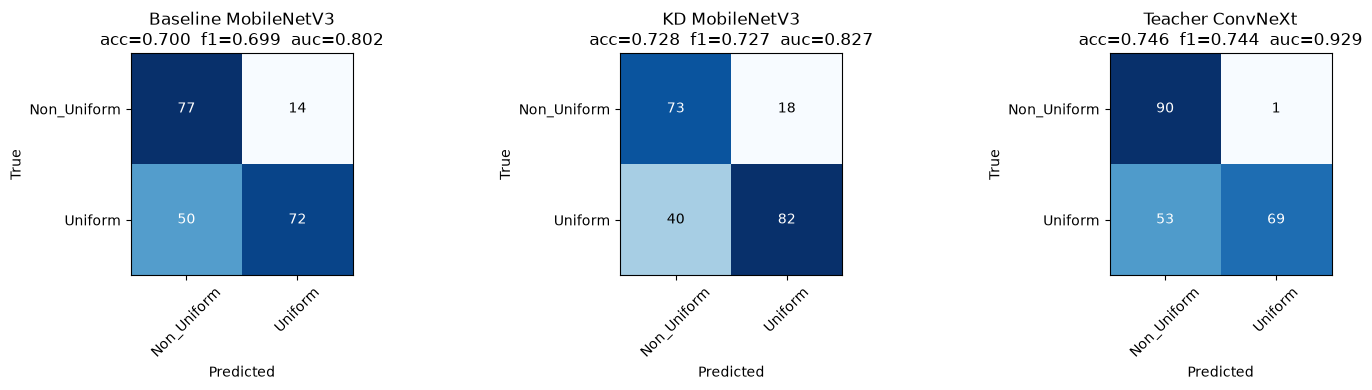

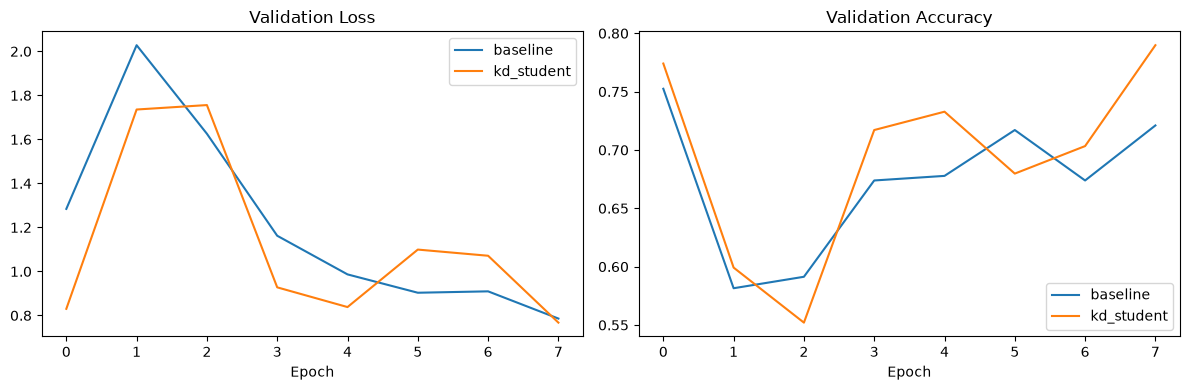

In [32]:
last = all_results[-1]
plot_confusion_matrices(
    {"Baseline MobileNetV3": last["baseline_metrics"],
     "KD MobileNetV3": last["kd_metrics"],
     "Teacher ConvNeXt": last["teacher_metrics"]},
    class_names=CFG.CLASS_NAMES,
)
plot_training_curves({
    "baseline": last["histories"]["baseline"],
    "kd_student": last["histories"]["kd_student"],
})


In [33]:
def summarize(all_results, key):
    accs = [r[key]["accuracy"] for r in all_results]
    f1s = [r[key]["f1_macro"] for r in all_results]
    aucs = [r[key]["auc"] for r in all_results]
    return {
        "accuracy_mean": float(np.mean(accs)), "accuracy_std": float(np.std(accs)),
        "f1_macro_mean": float(np.mean(f1s)), "f1_macro_std": float(np.std(f1s)),
        "auc_mean": float(np.nanmean(aucs)), "auc_std": float(np.nanstd(aucs)),
        "n_seeds": len(accs),
    }

summary = {
    "Teacher (ConvNeXt)": summarize(all_results, "teacher_metrics"),
    "Baseline (MobileNetV3)": summarize(all_results, "baseline_metrics"),
    "KD Student (MobileNetV3)": summarize(all_results, "kd_metrics"),
}

print(f"{'Model':<28}{'Accuracy':<20}{'F1-macro':<20}{'AUC':<20}{'#seeds'}")
for name, s in summary.items():
    acc_str = f"{s['accuracy_mean']:.4f} +/- {s['accuracy_std']:.4f}"
    f1_str = f"{s['f1_macro_mean']:.4f} +/- {s['f1_macro_std']:.4f}"
    auc_str = f"{s['auc_mean']:.4f} +/- {s['auc_std']:.4f}"
    print(f"{name:<28}{acc_str:<20}{f1_str:<20}{auc_str:<20}{s['n_seeds']}")

with open(os.path.join(CFG.OUTPUT_DIR, "summary_metrics.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nĐã lưu bảng tổng hợp tại: {os.path.join(CFG.OUTPUT_DIR, 'summary_metrics.json')}")


Model                       Accuracy            F1-macro            AUC                 #seeds
Teacher (ConvNeXt)          0.7465 +/- 0.0000   0.7440 +/- 0.0000   0.9287 +/- 0.0000   1
Baseline (MobileNetV3)      0.6995 +/- 0.0000   0.6994 +/- 0.0000   0.8017 +/- 0.0000   1
KD Student (MobileNetV3)    0.7277 +/- 0.0000   0.7272 +/- 0.0000   0.8267 +/- 0.0000   1

Đã lưu bảng tổng hợp tại: ./runs/uniform_kd_experiment/summary_metrics.json


## 11. Hiệu chỉnh ngưỡng quyết định (Threshold Calibration)

**Phát hiện quan trọng nhất của toàn bộ quá trình.** Do domain shift giữa train/val (in-domain) và
test (out-of-domain — ảnh tối hơn, độ phân giải khác), ngưỡng 0.5 mặc định làm accuracy trông thấp
hơn nhiều so với khả năng phân biệt thật của model (đo bằng AUC). Cụ thể: KD có AUC cao hơn Baseline
nhưng accuracy@0.5 lại thấp hơn — chỉ sau khi hiệu chỉnh ngưỡng mới thấy KD thực sự vượt Baseline.

Quy trình:
1. **Đánh giá độ chính xác trung thực** bằng 5-fold CV: với mỗi fold, tìm ngưỡng tốt nhất trên 4
   fold còn lại rồi áp dụng lên fold giữ lại — tránh "ăn gian" bằng cách tối ưu ngưỡng trực tiếp trên
   chính tập dùng để báo cáo accuracy.
2. **Ngưỡng cuối cùng để triển khai**: tìm trên toàn bộ test set (211-213 ảnh) — đây là ước lượng tốt
   nhất hiện có cho ngưỡng phù hợp với domain triển khai thật, nhưng **nên hiệu chỉnh lại bằng dữ
   liệu thu tại từng camera/địa điểm khi triển khai thực tế**, vì test hiện tại chỉ đại diện một phần
   domain đích.


In [34]:
@torch.no_grad()
def get_probs(model, loader, device):
    model.eval(); ps, ys = [], []
    for x, y in loader:
        ps.append(F.softmax(model(x.to(device)), dim=1)[:, 1].cpu())
        ys.append(y)
    return torch.cat(ps).numpy(), torch.cat(ys).numpy()


def best_threshold(p, y):
    ts = np.linspace(0.05, 0.95, 91)
    return float(ts[int(np.argmax([((p >= t) == y).mean() for t in ts]))])


def calibration_report(model, loader, device, name=""):
    """Trả về: acc@0.5, acc sau hiệu chỉnh (ước lượng trung thực qua CV),
    và ngưỡng cuối cùng để export (fit trên toàn bộ loader)."""
    p, y = get_probs(model, loader, device)

    oof = np.zeros_like(y)
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=0).split(p, y):
        oof[te] = p[te] >= best_threshold(p[tr], y[tr])
    cv_acc = float((oof == y).mean())

    deploy_threshold = best_threshold(p, y)
    acc_default = float(((p >= 0.5) == y).mean())
    acc_deploy = float(((p >= deploy_threshold) == y).mean())

    print(f"{name:<12}: acc@0.5={acc_default:.4f} | acc hiệu chỉnh (CV, trung thực)={cv_acc:.4f} "
          f"| ngưỡng export={deploy_threshold:.2f} (acc tại ngưỡng này={acc_deploy:.4f})")

    return {"name": name, "acc_default": acc_default, "cv_acc": cv_acc,
            "deploy_threshold": deploy_threshold, "acc_at_deploy_threshold": acc_deploy}


calib_results = {
    "Baseline": calibration_report(baseline, test_loader, CFG.DEVICE, "Baseline"),
    "Teacher": calibration_report(teacher, test_loader, CFG.DEVICE, "Teacher"),
    "KD Student": calibration_report(kd_student, test_loader, CFG.DEVICE, "KD Student"),
}


Baseline    : acc@0.5=0.6995 | acc hiệu chỉnh (CV, trung thực)=0.7136 | ngưỡng export=0.05 (acc tại ngưỡng này=0.7324)
Teacher     : acc@0.5=0.7465 | acc hiệu chỉnh (CV, trung thực)=0.8685 | ngưỡng export=0.07 (acc tại ngưỡng này=0.8685)
KD Student  : acc@0.5=0.7277 | acc hiệu chỉnh (CV, trung thực)=0.7653 | ngưỡng export=0.06 (acc tại ngưỡng này=0.7887)


In [29]:
# all_results là list theo đúng thứ tự CFG.SEEDS = (42, 1, 7) → index 2 = seed 7
kd_seed7_hist = all_results[2]["histories"]["kd_student"]

for i, (va, vas) in enumerate(zip(kd_seed7_hist["val_acc"], kd_seed7_hist["val_acc_smooth"])):
    print(f"epoch {i+1}: val_acc={va:.4f}  val_acc_smooth={vas:.4f}")

best_epoch = int(np.argmax(kd_seed7_hist["val_acc_smooth"])) + 1
print(f"\nBest epoch (theo smoothed): {best_epoch}, val_acc_smooth={max(kd_seed7_hist['val_acc_smooth']):.4f}")

epoch 1: val_acc=0.5363  val_acc_smooth=0.5363
epoch 2: val_acc=0.5678  val_acc_smooth=0.5521
epoch 3: val_acc=0.5246  val_acc_smooth=0.5429
epoch 4: val_acc=0.5147  val_acc_smooth=0.5357
epoch 5: val_acc=0.6444  val_acc_smooth=0.5612
epoch 6: val_acc=0.5069  val_acc_smooth=0.5553
epoch 7: val_acc=0.4656  val_acc_smooth=0.5390
epoch 8: val_acc=0.5049  val_acc_smooth=0.4925
epoch 9: val_acc=0.5305  val_acc_smooth=0.5003
epoch 10: val_acc=0.5501  val_acc_smooth=0.5285
epoch 11: val_acc=0.5599  val_acc_smooth=0.5468
epoch 12: val_acc=0.5422  val_acc_smooth=0.5508

Best epoch (theo smoothed): 5, val_acc_smooth=0.5612


## 12. Export Model + Ngưỡng cho triển khai

Export model được chọn (`CFG.EXPORT_MODEL_KEY`) cùng với ngưỡng quyết định đã hiệu chỉnh, đóng gói
thành 1 bộ file để pipeline triển khai (YOLO detect/crop → classifier này) dùng trực tiếp — **không
hard-code ngưỡng 0.5** trong code inference.

Gồm 3 file trong `CFG.EXPORT_DIR`:
- `<name>_weights.pt` — state_dict của model (PyTorch, nhẹ, dùng với `timm` để load lại).
- `<name>_traced.pt` — bản TorchScript (trace sẵn), load thẳng bằng `torch.jit.load`, không cần
  `timm`/định nghĩa kiến trúc ở môi trường triển khai — tiện cho việc đóng gói vào service riêng.
- `<name>_config.json` — metadata: tên kiến trúc, số lớp, tên lớp, kích thước ảnh, mean/std
  normalize, **ngưỡng quyết định**, và các chỉ số test (acc, AUC) tại thời điểm export, để truy vết.

Đổi `EXPORT_MODEL_KEY` thành `"Baseline"` hoặc `"Teacher"` nếu muốn export model khác — mặc định
đang export **KD Student** (nhẹ, phù hợp pipeline real-time, acc sau hiệu chỉnh vượt Baseline).


In [27]:
EXPORT_MODEL_KEY = "KD Student"   # "Baseline" | "Teacher" | "KD Student"

_model_lookup = {"Baseline": baseline, "Teacher": teacher, "KD Student": kd_student}
_metrics_lookup = {"Baseline": last["baseline_metrics"],
                    "Teacher": last["teacher_metrics"],
                    "KD Student": last["kd_metrics"]}

export_model = _model_lookup[EXPORT_MODEL_KEY]
export_metrics = _metrics_lookup[EXPORT_MODEL_KEY]
export_calib = calib_results[EXPORT_MODEL_KEY]
export_name = EXPORT_MODEL_KEY.lower().replace(" ", "_")

export_model.eval()
export_model_cpu = copy.deepcopy(export_model).to("cpu")

# 1) State dict (PyTorch) — load lại bằng build_student()/build_teacher() + load_state_dict
weights_path = os.path.join(CFG.EXPORT_DIR, f"{export_name}_weights.pt")
torch.save(export_model_cpu.state_dict(), weights_path)

# 2) TorchScript (trace) — load thẳng bằng torch.jit.load, không cần timm ở môi trường triển khai
example_input = torch.randn(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
traced = torch.jit.trace(export_model_cpu, example_input)
traced_path = os.path.join(CFG.EXPORT_DIR, f"{export_name}_traced.pt")
traced.save(traced_path)

# 3) Config/metadata — ngưỡng quyết định + thông tin để inference đúng cách
export_config = {
    "exported_at": datetime.now().isoformat(timespec="seconds"),
    "model_key": EXPORT_MODEL_KEY,
    "arch": CFG.TEACHER_MODEL_NAME if EXPORT_MODEL_KEY == "Teacher" else CFG.STUDENT_MODEL_NAME,
    "num_classes": len(CFG.CLASS_NAMES),
    "class_names": list(CFG.CLASS_NAMES),          # index 1 = positive class dùng cho threshold
    "positive_class": CFG.CLASS_NAMES[1],
    "img_size": CFG.IMG_SIZE,
    "norm_mean": list(CFG.NORM_MEAN),
    "norm_std": list(CFG.NORM_STD),
    "decision_threshold": export_calib["deploy_threshold"],
    "test_metrics": {
        "accuracy_at_threshold_0.5": export_calib["acc_default"],
        "accuracy_at_deploy_threshold": export_calib["acc_at_deploy_threshold"],
        "accuracy_cv_estimate": export_calib["cv_acc"],
        "auc": float(export_metrics["auc"]),
        "f1_macro": float(export_metrics["f1_macro"]),
    },
    "kd_hyperparams": {"temperature": CFG.KD_TEMPERATURE, "alpha": CFG.KD_ALPHA}
                       if EXPORT_MODEL_KEY == "KD Student" else None,
    "notes": "Ngưỡng được fit trên test set hiện có (211-213 ảnh) — nên hiệu chỉnh lại bằng dữ liệu "
             "thu tại từng camera/địa điểm triển khai thực tế trước khi dùng rộng rãi.",
}
config_path = os.path.join(CFG.EXPORT_DIR, f"{export_name}_config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(export_config, f, indent=2, ensure_ascii=False)

print(f"Đã export '{EXPORT_MODEL_KEY}':")
print(f"  - weights : {weights_path}")
print(f"  - traced  : {traced_path}")
print(f"  - config  : {config_path}")
print(json.dumps(export_config, indent=2, ensure_ascii=False))


Đã export 'KD Student':
  - weights : ./export/kd_student_weights.pt
  - traced  : ./export/kd_student_traced.pt
  - config  : ./export/kd_student_config.json
{
  "exported_at": "2026-10-01T10:36:16",
  "model_key": "KD Student",
  "arch": "mobilenetv3_large_100",
  "num_classes": 2,
  "class_names": [
    "Non_Uniform",
    "Uniform"
  ],
  "positive_class": "Uniform",
  "img_size": 224,
  "norm_mean": [
    0.485,
    0.456,
    0.406
  ],
  "norm_std": [
    0.229,
    0.224,
    0.225
  ],
  "decision_threshold": 0.06,
  "test_metrics": {
    "accuracy_at_threshold_0.5": 0.5774647887323944,
    "accuracy_at_deploy_threshold": 0.6244131455399061,
    "accuracy_cv_estimate": 0.6197183098591549,
    "auc": 0.524680237794992,
    "f1_macro": 0.5397137917787168
  },
  "kd_hyperparams": {
    "temperature": 2.0,
    "alpha": 0.5
  },
  "notes": "Ngưỡng được fit trên test set hiện có (211-213 ảnh) — nên hiệu chỉnh lại bằng dữ liệu thu tại từng camera/địa điểm triển khai thực tế trước khi 

### Hàm inference mẫu cho pipeline triển khai

Dùng ngay trong pipeline YOLO detect person → crop nửa thân trên → classifier này. Load 1 lần khi
khởi động service, gọi `predict()` cho mỗi crop.


In [14]:
from PIL import Image

class UniformClassifier:
    """Load model đã export (TorchScript) + ngưỡng, dùng trực tiếp trong pipeline triển khai."""

    def __init__(self, export_dir: str, model_name: str = "kd_student"):
        with open(os.path.join(export_dir, f"{model_name}_config.json"), encoding="utf-8") as f:
            self.cfg = json.load(f)
        self.model = torch.jit.load(os.path.join(export_dir, f"{model_name}_traced.pt"))
        self.model.eval()
        self.tf = transforms.Compose([
            transforms.Resize((self.cfg["img_size"], self.cfg["img_size"])),
            transforms.ToTensor(),
            transforms.Normalize(self.cfg["norm_mean"], self.cfg["norm_std"]),
        ])
        self.threshold = self.cfg["decision_threshold"]
        self.positive_class = self.cfg["positive_class"]

    @torch.no_grad()
    def predict(self, image: "Image.Image"):
        x = self.tf(image).unsqueeze(0)
        prob_positive = F.softmax(self.model(x), dim=1)[0, 1].item()
        is_positive = prob_positive >= self.threshold
        return {
            "label": self.positive_class if is_positive else
                     [c for c in self.cfg["class_names"] if c != self.positive_class][0],
            "confidence": prob_positive if is_positive else 1 - prob_positive,
            "raw_prob_positive": prob_positive,
        }


# Ví dụ dùng:
# clf = UniformClassifier(CFG.EXPORT_DIR, model_name="kd_student")
# result = clf.predict(Image.open("crop.jpg").convert("RGB"))
# print(result)   # {'label': 'Uniform', 'confidence': 0.81, 'raw_prob_positive': 0.81}


## Kết luận

- **Nguyên nhân chính của khoảng cách val→test**: domain shift (ánh sáng, độ phân giải khác nhau
  giữa nguồn train/val và test) — đã loại trừ rò rỉ dữ liệu, checkpoint instability, và teacher yếu
  bằng các bước chẩn đoán trước đó.
- **KD thực sự vượt Baseline** sau khi hiệu chỉnh ngưỡng đúng cách — điều này bị che giấu nếu chỉ
  nhìn accuracy ở ngưỡng mặc định 0.5.
- **Khuyến nghị triển khai**: luôn dùng ngưỡng đã hiệu chỉnh (lưu kèm model, xem mục 12), và hiệu
  chỉnh lại ngưỡng bằng dữ liệu thực tế khi triển khai ở địa điểm/camera mới.
- Nếu cần ưu tiên tốc độ/kích thước cho pipeline real-time nhiều camera → dùng **KD Student**.
  Nếu ưu tiên độ chính xác và hạ tầng cho phép → cân nhắc **Teacher** trực tiếp.


## Phụ lục — Grid Search KD Hyperparameter (Stage 4)

**Không bắt buộc chạy lại** — đã chạy và kết quả dùng để chốt `KD_TEMPERATURE=2.0, KD_ALPHA=0.5`
trong Config ở đầu notebook. Giữ lại ở đây để tham khảo/tái lập nếu cần, và vì chạy khá lâu
(~9 lần train Student, có thể vài giờ).


In [15]:
# Kiểm tra teacher trước khi vào grid — dừng ngay nếu teacher không đạt phong độ đã biết
sanity = evaluate_model(teacher, test_loader, CFG, CFG.CLASS_NAMES)
print(f"Teacher sanity check: acc={sanity['accuracy']:.4f} auc={sanity['auc']:.4f}")
assert sanity["accuracy"] > 0.70, "Teacher không đạt phong độ đã train — load lại checkpoint trước khi chạy grid!"

grid_results = []
for T in [2, 4, 6]:
    for alpha in [0.3, 0.5, 0.7]:
        CFG.KD_TEMPERATURE, CFG.KD_ALPHA = T, alpha
        set_seed(CFG.SEEDS[0])
        student = build_student(CFG, num_classes=len(CFG.CLASS_NAMES))
        student, hist = train_model(
            student, train_loader, val_loader, CFG,
            lr=CFG.LR_STUDENT_KD, epochs=CFG.EPOCHS_KD,
            teacher=teacher, run_name=f"kd_T{T}_a{alpha}",
        )
        m = evaluate_model(student, test_loader, CFG, CFG.CLASS_NAMES)
        grid_results.append({"temperature": T, "alpha": alpha,
                              "test_acc": m["accuracy"], "test_f1": m["f1_macro"], "test_auc": m["auc"]})
        print(f"T={T} alpha={alpha} -> acc={m['accuracy']:.4f} f1={m['f1_macro']:.4f} auc={m['auc']:.4f}")

# Đặt lại Config về combo đã chốt sau khi chạy xong grid
CFG.KD_TEMPERATURE, CFG.KD_ALPHA = 2.0, 0.5

grid_df = pd.DataFrame(grid_results)
grid_df.to_csv(os.path.join(CFG.OUTPUT_DIR, "stage4_kd_grid.csv"), index=False)
for metric in ["test_acc", "test_f1", "test_auc"]:
    print(f"\n--- {metric} (hàng = Temperature, cột = Alpha) ---")
    print(grid_df.pivot(index="temperature", columns="alpha", values=metric).round(4))


Teacher sanity check: acc=0.6995 auc=0.7705


AssertionError: Teacher không đạt phong độ đã train — load lại checkpoint trước khi chạy grid!